<a href="https://colab.research.google.com/github/pooja97/Body_posture_recognition/blob/main/mediapipe1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

!pip3 install gdown
!pip3 install mediapipe

     |████████████████████████████████| 32.8 MB 1.7 MB/s 


In [2]:
import cv2
import mediapipe as mp
import gdown
from google.colab.patches import cv2_imshow as gc_cv
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
mp_holistic = mp.solutions.holistic # Holistic model

In [4]:
mp_pose = mp.solutions.pose
draw = mp.solutions.drawing_utils

In [5]:
pose_video = mp_pose.Pose(static_image_mode=False, min_detection_confidence=0.7,
                          min_tracking_confidence=0.7)

In [127]:
video_list = ['19KfoyxeTGlu6wLdStsYjh3jV-gyZX7Ub','1SuWkn4XcKwFBNr1xMaQrzc7U6FYTTqML',
              '1rvk8UsyaqMuMvfvd7_euqRMtQd0O4CAq','1A_P4pyDMBETzKlRF6Dk4ROutJMcVW-bf',
              '13TIZ1DCfASsyqxIBc35ey40NRulIa0G_','1sbLpn94Jc6KxSFQBm3JGLtyeNVBtQcXw',
              '1W36rZ-vzSpLsdx_kQ-6ivCOiOHjht6oT','1EdSVg_TIiijW5d6mPYa192viNn2spGz3',
              '1Rk63pnY8QozQNLcsFzNpQIwIi3Q4bcZE','1wGOQCQCAs2Z2NLfasOS7bOFZhzy_7RKn',
              '1BKjRzHYMwy2XuNcEkz4Q0uQa8CKoiweA','1Rk63pnY8QozQNLcsFzNpQIwIi3Q4bcZE']


In [128]:
keypoints = []
no = 0
for i in video_list:
  gdown.download(
    'https://drive.google.com/u/0/uc?id={0}&confirm=t'.format(i),
    '/content/frames/video{0}.mp4'.format(no),
    quiet = False
  )
  capture = cv2.VideoCapture("/content/frames/video{0}.mp4".format(no))
  mpPose = mp.solutions.pose
  pose = mpPose.Pose()
  frame_width = int(capture.get(3))
  frame_height = int(capture.get(4))
  size = (frame_width, frame_height)
  # result = cv2.VideoWriter("/content/output", cv2.VideoWriter_fourcc(*"MJPG"), 10, size)
  results=0
  count=0
  while True:
    success, img = capture.read()
    if success == True:
      imgRGB = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
      results = pose.process(imgRGB)
      if results.pose_landmarks:
        # print(results.pose_landmarks.landmark)
        # draw.draw_landmarks(img, results.pose_landmarks, mpPose.POSE_CONNECTIONS)
        X = results.pose_landmarks.landmark
        for data_point in X:
          keypoints.append({
                          'X': data_point.x,
                          'Y': data_point.y,
                          'Z': data_point.z,
                          'Visibility': data_point.visibility,
                          })
        count += 1
        if count > 500:
          count = 0
          break
        # result.write(img)
  # print("Len ", len(results.pose_landmarks.landmark))
  # print("RESULTS",results.pose_landmarks.landmark)
  no = no + 1
#   cv2.waitKey(1)


  capture.release()
  #result.release()
  cv2.destroyAllWindows()
  print(len(keypoints))

Downloading...
From: https://drive.google.com/u/0/uc?id=19KfoyxeTGlu6wLdStsYjh3jV-gyZX7Ub&confirm=t
To: /content/frames/video0.mp4
100%|██████████| 177M/177M [00:01<00:00, 143MB/s]


16533


Downloading...
From: https://drive.google.com/u/0/uc?id=1SuWkn4XcKwFBNr1xMaQrzc7U6FYTTqML&confirm=t
To: /content/frames/video1.mp4
100%|██████████| 64.1M/64.1M [00:00<00:00, 165MB/s]


33066


Downloading...
From: https://drive.google.com/u/0/uc?id=1rvk8UsyaqMuMvfvd7_euqRMtQd0O4CAq&confirm=t
To: /content/frames/video2.mp4
100%|██████████| 134M/134M [00:00<00:00, 155MB/s]


...

165330


Downloading...
From: https://drive.google.com/u/0/uc?id=1BKjRzHYMwy2XuNcEkz4Q0uQa8CKoiweA&confirm=t
To: /content/frames/video10.mp4
100%|██████████| 203M/203M [00:03<00:00, 53.3MB/s]


181863


Downloading...
From: https://drive.google.com/u/0/uc?id=1Rk63pnY8QozQNLcsFzNpQIwIi3Q4bcZE&confirm=t
To: /content/frames/video11.mp4
100%|██████████| 170M/170M [00:02<00:00, 60.8MB/s]


198396


In [34]:
#print(keypoints)

[{'X': 0.5142098665237427, 'Y': 0.308681845664978, 'Z': -0.5630786418914795, 'Visibility': 0.9999996423721313}, {'X': 0.5386240482330322, 'Y': 0.2543327808380127, 'Z': -0.5133649110794067, 'Visibility': 0.9999994039535522}, {'X': 0.5526065826416016, 'Y': 0.25707852840423584, 'Z': -0.5130575299263, 'Visibility': 0.9999991655349731}, {'X': 0.5655395984649658, 'Y': 0.25942718982696533, 'Z': -0.5125388503074646, 'Visibility': 0.9999992847442627}, {'X': 0.49357932806015015, 'Y': 0.24630165100097656, 'Z': -0.5196751356124878, 'Visibility': 0.9999992847442627}, {'X': 0.4783545136451721, 'Y': 0.24446487426757812, 'Z': -0.5187979340553284, 'Visibility': 0.999998927116394}, {'X': 0.46582746505737305, 'Y': 0.24410569667816162, 'Z': -0.5189492106437683, 'Visibility': 0.9999988079071045}, {'X': 0.5852269530296326, 'Y': 0.2953253984451294, 'Z': -0.23415270447731018, 'Visibility': 0.9999986886978149}, {'X': 0.4462440013885498, 'Y': 0.2750053405761719, 'Z': -0.26242390275001526, 'Visibility': 0.999999

In [129]:
keypoints_df = pd.DataFrame.from_dict(keypoints)


In [137]:
keypoints_df.head()

,X,Y,Z,Visibility
0,0.514210,0.308682,-0.563079,1.000000
1,0.538624,0.254333,-0.513365,0.999999
2,0.552607,0.257079,-0.513058,0.999999
3,0.565540,0.259427,-0.512539,0.999999
4,0.493579,0.246302,-0.519675,0.999999


In [138]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()  
import numpy as np

In [139]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2)
kmeans.fit(keypoints_df)
y_kmeans = kmeans.predict(keypoints_df)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:16: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  app.launch_new_instance()


Text(0.5, 0, 'Z Label')

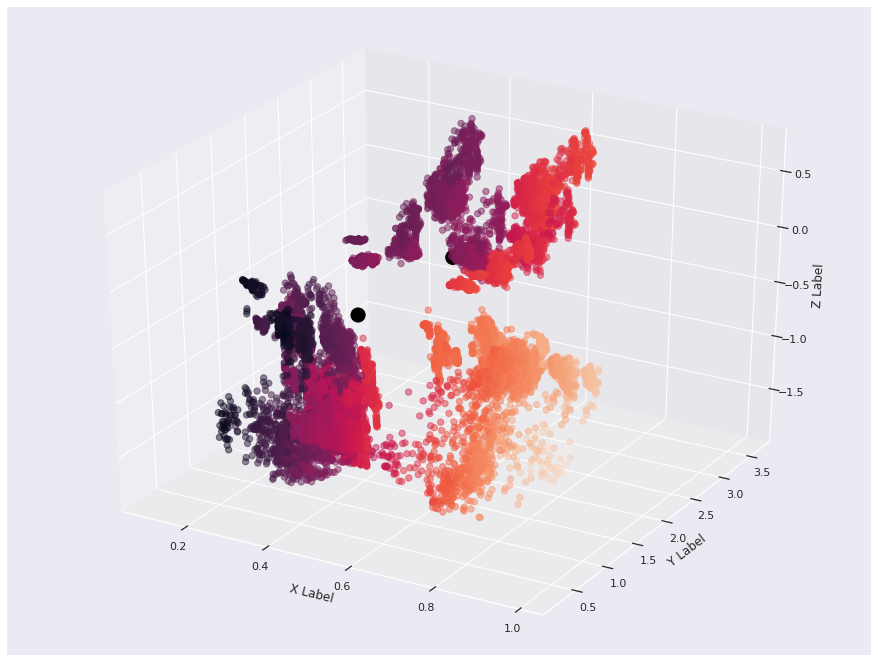

In [141]:
import re, seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

#fig = plt.figure(figsize=(12, 9))
#ax = Axes3D(fig)

#Sampling data to avoid overplotting
y = keypoints_df.iloc[:20000,1]
x = keypoints_df.iloc[:20000,0]
z = keypoints_df.iloc[:20000,2]


fig = plt.figure(figsize=(12,9))
ax = Axes3D(fig)
fig.add_axes(ax)

# get colormap from seaborn
cmap = ListedColormap(sns.color_palette("rocket", 256).as_hex())

# plot
centers = kmeans.cluster_centers_
sc1 = ax.scatter(centers[:,0], centers[:,1], c ='black', s =200, alpha = 1);
sc = ax.scatter(x, y, z, c=x, s=40, marker='o', cmap=cmap, alpha=0.5)


ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')



In [134]:
len(keypoints_df['X'])

198396